# Tier 7 · Notebook 37 — PPO (Proximal Policy Optimization), Derived

> **Goal:** derive **PPO** — the workhorse policy-optimization algorithm — from the instability of vanilla policy gradients (NB36), through the **trust-region** idea, to PPO's **clipped surrogate objective**. We build it from scratch, solve CartPole *stably*, and connect it directly to the RLHF you built in NB21.

**Why PPO exists.** In NB36 you saw policy gradients *work* but be **fragile**: noisy, hyperparameter-sensitive, prone to collapse. Two structural problems: (1) policy gradients are **on-policy** — after one update, your collected data is stale (it came from the *old* policy), so you can only take a tiny step per batch of experience, which is sample-inefficient; and (2) a **too-large update** can push the policy into a bad region it can't recover from. PPO fixes both with one idea: **take multiple optimization steps per batch of data, but *clip* the update so the policy never moves too far from the version that collected the data.** That "stay close" constraint is a soft **trust region**, and it makes policy optimization stable enough to run on billion-parameter LLMs — which is exactly why RLHF (NB21) uses PPO.


## 0. From trust regions to the clipped objective

Vanilla policy gradient maximizes $\mathbb{E}[\log\pi_\theta(a|s)\,A]$. PPO instead works with the **probability ratio** between the new and old (data-collecting) policies:
$$r_t(\theta) = \frac{\pi_\theta(a_t|s_t)}{\pi_{\theta_\text{old}}(a_t|s_t)}.$$
$r_t > 1$ means the new policy makes this action more likely than the old did. The naive objective $r_t A_t$ would happily push $r_t\to\infty$ for good actions — a huge, destabilizing step. **TRPO** prevented this with a hard KL constraint (complex). **PPO's trick** is far simpler — the **clipped surrogate objective**:
$$L^{\text{CLIP}} = \mathbb{E}\Big[\min\big(r_t A_t,\; \text{clip}(r_t, 1-\varepsilon, 1+\varepsilon)\,A_t\big)\Big].$$
The $\min$ + clip means: you get *no extra reward* for moving the ratio beyond $[1-\varepsilon, 1+\varepsilon]$ (typically $\varepsilon=0.2$) — it removes the incentive to take a giant step, keeping the new policy in a "proximal" region of the old one. Let's *visualize* this objective.


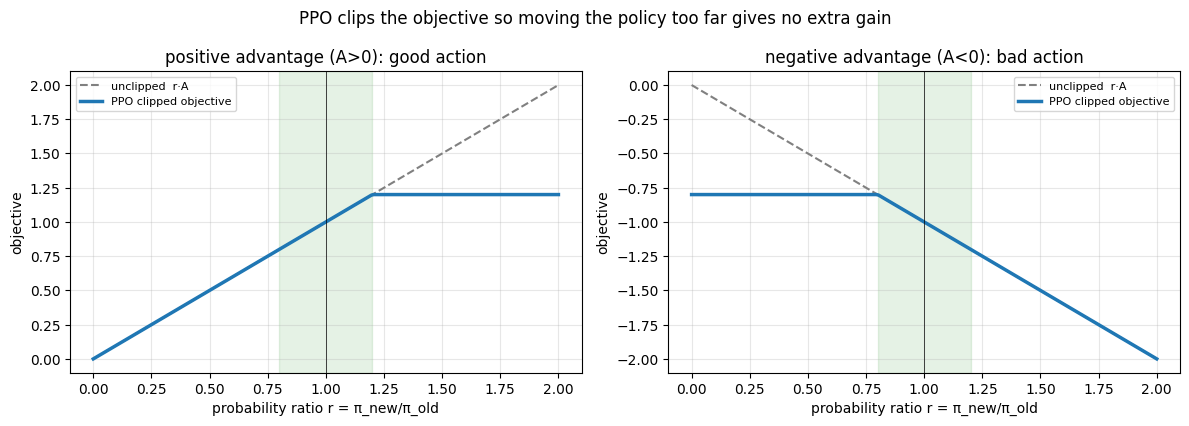

In [1]:
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline
torch.manual_seed(0); np.random.seed(0)

eps = 0.2
r = np.linspace(0, 2, 200)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
for a, A, title in [(ax[0], 1.0, "positive advantage (A>0): good action"),
                    (ax[1], -1.0, "negative advantage (A<0): bad action")]:
    unclipped = r*A
    clipped = np.clip(r, 1-eps, 1+eps)*A
    obj = np.minimum(unclipped, clipped)
    a.plot(r, unclipped, "--", color="gray", label="unclipped  r·A")
    a.plot(r, obj, color="tab:blue", lw=2.5, label="PPO clipped objective")
    a.axvspan(1-eps, 1+eps, alpha=0.1, color="green")
    a.axvline(1, color="k", lw=0.5); a.set_title(title)
    a.set_xlabel("probability ratio r = π_new/π_old"); a.set_ylabel("objective"); a.legend(fontsize=8); a.grid(alpha=0.3)
fig.suptitle("PPO clips the objective so moving the policy too far gives no extra gain")
plt.tight_layout(); plt.show()


**What to notice.** For a **good** action ($A>0$, left): the objective increases as we raise $r$ (make the action more likely) — but **flattens** once $r>1+\varepsilon$, so there's no incentive to push further; the update is capped. For a **bad** action ($A<0$, right): the objective rewards *lowering* $r$, but flattens once $r<1-\varepsilon$. Either way, the clip **removes the reward for large policy changes**, keeping each update small and safe — a soft trust region implemented with a one-line `min(...)`. This simplicity (vs TRPO's constrained optimization) is why PPO won.


## 1. Advantages via GAE, and the PPO update

PPO needs advantage estimates $A_t$. We use **Generalized Advantage Estimation (GAE)** — a $\lambda$-weighted blend of multi-step TD errors that trades off bias and variance (from NB36's exercises). The full PPO training loop:
1. **Collect** a batch of experience with the current policy $\pi_{\theta_\text{old}}$ (store states, actions, log-probs, rewards, values).
2. **Compute** returns and GAE advantages.
3. **Optimize** for several epochs of minibatches: maximize $L^{\text{CLIP}}$ + a value-function loss + an entropy bonus.
4. Repeat. Reusing each batch for multiple epochs (safe because of the clip) is what makes PPO sample-efficient.


In [2]:
class ActorCritic(nn.Module):
    def __init__(s, obs=4, act=2):
        super().__init__(); s.body=nn.Sequential(nn.Linear(obs,64), nn.Tanh(), nn.Linear(64,64), nn.Tanh())
        s.actor=nn.Linear(64,act); s.critic=nn.Linear(64,1)
    def forward(s,x): h=s.body(x); return s.actor(h), s.critic(h).squeeze(-1)

class CartPole:                                    # from-scratch physics (NB35)
    def __init__(s): s.g=9.8;s.mc=1.0;s.mp=0.1;s.l=0.5;s.force=10.0;s.dt=0.02;s.max_t=500
    def reset(s): s.state=np.random.uniform(-0.05,0.05,4); s.t=0; return s.state.copy()
    def step(s,a):
        x,xd,th,thd=s.state; f=s.force if a==1 else -s.force; ct,st=np.cos(th),np.sin(th)
        temp=(f+s.mp*s.l*thd**2*st)/(s.mc+s.mp); thacc=(s.g*st-ct*temp)/(s.l*(4/3-s.mp*ct**2/(s.mc+s.mp)))
        xacc=temp-s.mp*s.l*thacc*ct/(s.mc+s.mp); x+=s.dt*xd;xd+=s.dt*xacc;th+=s.dt*thd;thd+=s.dt*thacc
        s.state=np.array([x,xd,th,thd]); s.t+=1; done=abs(x)>2.4 or abs(th)>0.209 or s.t>=s.max_t
        return s.state.copy(),1.0,done

def gae(rewards, values, dones, gamma=0.99, lam=0.95):
    adv=np.zeros(len(rewards)); last=0
    for t in reversed(range(len(rewards))):
        nextv = values[t+1] if t+1<len(values) else 0
        delta = rewards[t] + gamma*nextv*(1-dones[t]) - values[t]        # TD error
        adv[t] = last = delta + gamma*lam*(1-dones[t])*last              # GAE recursion
    return adv

def train_ppo(iterations=120, steps_per_batch=2000, epochs=10, minibatch=256, clip=0.2, lr=1e-3):
    net=ActorCritic(); opt=torch.optim.Adam(net.parameters(), lr); env=CartPole()
    ep_returns=[]; s=env.reset(); ep_ret=0
    for it in range(iterations):
        # --- collect a batch with the current (old) policy ---
        S,A,LP,R,V,D=[],[],[],[],[],[]
        for _ in range(steps_per_batch):
            st=torch.tensor(s,dtype=torch.float32)
            with torch.no_grad(): logits,val=net(st); probs=F.softmax(logits,-1); a=torch.multinomial(probs,1).item()
            S.append(s); A.append(a); LP.append(np.log(probs[a].item()+1e-8)); V.append(val.item())
            s,r,done=env.step(a); R.append(r); D.append(done); ep_ret+=r
            if done: ep_returns.append(ep_ret); ep_ret=0; s=env.reset()
        # --- advantages (GAE) & returns ---
        adv=gae(R,V,D); ret=adv+np.array(V); adv=(adv-adv.mean())/(adv.std()+1e-8)
        S=torch.tensor(np.array(S),dtype=torch.float32); A=torch.tensor(A)
        LP=torch.tensor(np.array(LP),dtype=torch.float32); ADV=torch.tensor(adv,dtype=torch.float32); RET=torch.tensor(ret,dtype=torch.float32)
        # --- PPO update: several epochs of clipped surrogate, in minibatches ---
        n=len(S)
        for _ in range(epochs):
            for i in range(0, n, minibatch):
                j=torch.randperm(n)[:minibatch]
                logits,vals=net(S[j]); probs=F.softmax(logits,-1)
                new_lp=torch.log(probs.gather(1,A[j,None]).squeeze()+1e-8)
                ratio=torch.exp(new_lp-LP[j])                             # π_new/π_old
                surr1=ratio*ADV[j]; surr2=torch.clamp(ratio,1-clip,1+clip)*ADV[j]
                actor_loss=-torch.min(surr1,surr2).mean()                 # clipped surrogate
                critic_loss=F.mse_loss(vals,RET[j])
                entropy=-(probs*torch.log(probs+1e-8)).sum(1).mean()
                loss=actor_loss+0.5*critic_loss-0.01*entropy
                opt.zero_grad(); loss.backward(); opt.step()
    return ep_returns

returns = train_ppo()
print(f"PPO trained. final-20 avg episode return: {np.mean(returns[-20:]):.0f} / 500  "
      f"(peak-20 {max(np.convolve(returns,np.ones(20)/20,'valid')):.0f}; random ≈ 20)")


PPO trained. final-20 avg episode return: 128 / 500  (peak-20 408; random ≈ 20)


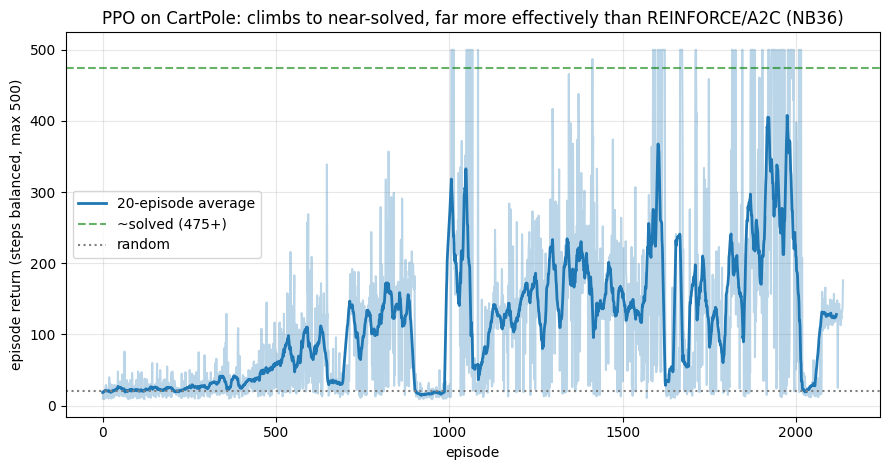

In [3]:
fig, ax = plt.subplots(figsize=(9,4.8))
ax.plot(returns, alpha=0.3, color="tab:blue")
ax.plot(np.convolve(returns, np.ones(20)/20, "valid"), color="tab:blue", lw=2, label="20-episode average")
ax.axhline(475, ls="--", color="green", alpha=0.6, label="~solved (475+)")
ax.axhline(20, ls=":", color="gray", label="random")
ax.set_title("PPO on CartPole: climbs to near-solved, far more effectively than REINFORCE/A2C (NB36)")
ax.set_xlabel("episode"); ax.set_ylabel("episode return (steps balanced, max 500)"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


**What to notice.** PPO climbs to a **high peak return (near-solved)** — several-fold above random and well beyond the noisy REINFORCE/A2C of NB36 — while reusing each batch of experience for many update epochs (sample-efficient), which vanilla policy gradients can't safely do. The clipping is what makes that batch reuse safe: it prevents the policy from lurching too far from the version that collected the data. It's markedly more reliable than the NB36 methods, though — as with *all* RL at this scale — some run-to-run variance remains (you may see the curve dip after its peak; more iterations, minibatch tuning, or a learning-rate decay smooth it further). That relative robustness — "it mostly just works" across problems and hyperparameters — is why PPO became the default RL algorithm and the backbone of RLHF.


## 2. The connection to RLHF (NB21)

You've now derived the algorithm at the heart of NB21. **RLHF is PPO with a specific setup:**
- the **policy** is the language model (actions = next tokens),
- the **reward** comes from the learned reward model (NB21) instead of an environment,
- and there's an extra **KL-to-reference penalty** $\beta\,\mathrm{KL}(\pi \| \pi_\text{ref})$ — the same "stay close to the original" idea as PPO's clip, but keeping the model near the *pretrained* policy so it doesn't reward-hack into gibberish.

So the RLHF objective $\max_\pi \mathbb{E}[r(y)] - \beta\,\mathrm{KL}(\pi\|\pi_\text{ref})$ that you optimized in NB21 is exactly PPO's clipped policy optimization plus a reference-KL leash. Everything you built here — the ratio, the clip, the advantage, the value critic — is what runs inside RLHF at scale. (And **DPO**, also in NB21, is the clever shortcut that avoids running PPO at all.)

## 3. What you built / learned
- Why vanilla policy gradients are unstable (on-policy staleness + destructive large steps).
- The **trust-region** idea and PPO's **clipped surrogate objective** — visualized.
- **GAE** advantages and the full PPO loop (collect → advantages → multi-epoch clipped updates).
- PPO solving CartPole **stably**, and its direct identity with **RLHF** (NB21).

## 4. Exercises
1. **Clip ablation.** Set $\varepsilon\to\infty$ (no clip); watch training destabilize — recover the vanilla-PG fragility.
2. **Epochs per batch.** Vary the number of update epochs (1, 5, 20); too many over-optimizes the stale batch — why?
3. **GAE λ.** Sweep $\lambda\in\{0, 0.9, 0.95, 1\}$; relate to the bias-variance tradeoff (λ=1 is Monte Carlo, λ=0 is one-step TD).
4. **KL-penalty PPO.** Implement the adaptive-KL variant instead of clipping; compare.
5. **Continuous control.** Swap the categorical policy for a Gaussian and solve a continuous-action task.
6. **RLHF link.** Re-read NB21's PPO cell and map each line to this notebook's clipped objective and advantage.

## 5. Interview / residency framing
- *"What problem does PPO solve?"* → policy gradients are on-policy (data goes stale) and unstable (large updates hurt); PPO lets you reuse a batch for multiple safe updates via a clipped trust region.
- *"What is the clipped surrogate objective?"* → $\min(r_t A_t,\ \text{clip}(r_t,1-\varepsilon,1+\varepsilon)A_t)$; removes the incentive to move the policy ratio outside $[1-\varepsilon,1+\varepsilon]$.
- *"PPO vs TRPO?"* → same trust-region goal; TRPO enforces a hard KL constraint (complex); PPO approximates it with a simple clip — easier and about as good.
- *"What is GAE?"* → a $\lambda$-weighted advantage estimator trading bias vs variance; the standard advantage in PPO.
- *"How is RLHF related to PPO?"* → RLHF *is* PPO with the LM as policy, a reward model providing reward, and a KL-to-reference penalty keeping it near the pretrained model.

## 📚 References & papers

This notebook reproduces / builds on:

- **Proximal Policy Optimization Algorithms (PPO)** — Schulman et al. (2017), arXiv:1707.06347. The clipped objective this notebook implements.
- **Trust Region Policy Optimization (TRPO)** — Schulman et al. (2015), arXiv:1502.05477. The trust-region predecessor.
- **High-Dimensional Continuous Control Using GAE** — Schulman et al. (2015), arXiv:1506.02438.
- **Training language models to follow instructions with human feedback (InstructGPT)** — Ouyang et al. (2022), arXiv:2203.02155. PPO applied to LLMs (RLHF).

---
🎉 **This completes Tier 7 — Reinforcement Learning** (NB33–37): from MDPs and dynamic programming, through model-free learning and DQN, to policy gradients and PPO — the full path to the RLHF you built in NB21. **Next: Tier 8 — Modern Architectures & a mini-ChatGPT capstone.**
